In [ ]:
from logging_module import setup_logging
from typing import TypedDict, NotRequired
from langgraph.graph import StateGraph, START, END

logger = setup_logging()
logger.info("logging initialized")

2026-05-29T01:27:56.911105Z [info     ] logging initialized           


In [2]:
class AgentState(TypedDict):
    name: str
    age: int
    final: NotRequired[str]

In [3]:
def first_node(state: AgentState) -> AgentState:
    """First Node of the sequence"""
    state["final"] = f"Hi {state['name']}"
    return state


def second_node(state: AgentState) -> AgentState:
    """Second Node of the sequence"""
    state["final"] = f"You are {state['age']}"
    return state

In [4]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.set_finish_point("second_node")
app = graph.compile()

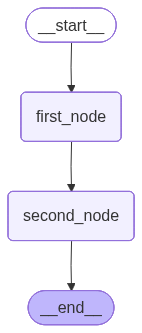

In [5]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke({"name": "Sree", "age": 30})

In [7]:
result

{'name': 'Sree', 'age': 30, 'final': 'You are 30'}

In [8]:
from typing import List


class AgentState3(TypedDict):
    name: str
    age: int
    skills: List[str]
    final: str

In [9]:
def first_node_1(state: AgentState3) -> AgentState3:
    """First Node of the sequence"""
    state["final"] = f"Hi {state['name']}"
    return state


def second_node_1(state: AgentState3) -> AgentState3:
    """Second Node of the sequence"""
    state["final"] = state["final"] + f", You are {state['age']}. "
    return state


def third_node_1(state: AgentState3) -> AgentState3:
    """Third Node of the sequence"""
    state["final"] = state["final"] + f"You have skills in {", ".join(state['skills'])}"
    return state

In [10]:
graph_1 = StateGraph(AgentState3)

graph_1.add_node("first_node", first_node_1)
graph_1.add_node("second_node", second_node_1)
graph_1.add_node("third_node", third_node_1)

graph_1.set_entry_point("first_node")
graph_1.add_edge("first_node", "second_node")
graph_1.add_edge("second_node", "third_node")
graph_1.set_finish_point("third_node")
app_1 = graph_1.compile()

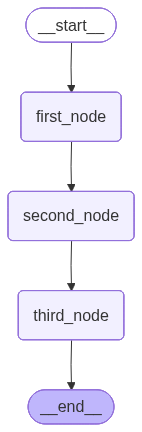

In [11]:
from IPython.display import Image, display

display(Image(app_1.get_graph().draw_mermaid_png()))

In [12]:
result = app_1.invoke(
    {"name": "Sree", "age": 30, "skills": ["Python", "JS"], "final": ""}
)

In [13]:
result

{'name': 'Sree',
 'age': 30,
 'skills': ['Python', 'JS'],
 'final': 'Hi Sree, You are 30. You have skills in Python, JS'}

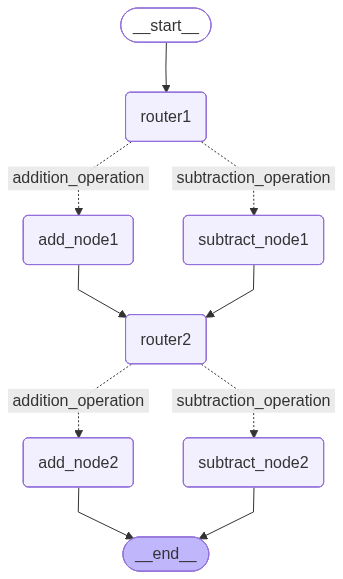

In [39]:
class AgentState4(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation1: str
    operation2: str
    finalNumber1: int
    finalNumber2: int


def adder1(state: AgentState4) -> AgentState4:
    """Adds 2 Numbers"""

    state["finalNumber1"] = state["number1"] + state["number2"]
    return state


def subtracter1(state: AgentState4) -> AgentState4:
    """Subtract 2 Numbers"""

    state["finalNumber1"] = state["number1"] - state["number2"]
    return state


def adder2(state: AgentState4) -> AgentState4:
    """Adds 2 Numbers"""

    state["finalNumber2"] = state["number3"] + state["number4"]
    return state


def subtracter2(state: AgentState4) -> AgentState4:
    """Subtract 2 Numbers"""

    state["finalNumber2"] = state["number3"] - state["number4"]
    return state


def decide_next_operation1(state: AgentState4) -> AgentState4:
    """This code will decide the next phase"""
    if state["operation1"] == "+":
        return "addition_operation"
    elif state["operation1"] == "-":
        return "subtraction_operation"


def decide_next_operation2(state: AgentState4) -> AgentState4:
    """This code will decide the next phase"""
    if state["operation2"] == "+":
        return "addition_operation"
    elif state["operation2"] == "-":
        return "subtraction_operation"


graph_4 = StateGraph(AgentState4)

graph_4.add_node("add_node1", adder1)
graph_4.add_node("subtract_node1", subtracter1)
graph_4.add_node("add_node2", adder2)
graph_4.add_node("subtract_node2", subtracter2)
graph_4.add_node("router1", lambda state: state)
graph_4.add_node("router2", lambda state: state)

graph_4.add_edge(START, "router1")
graph_4.add_conditional_edges(
    "router1",
    decide_next_operation1,
    {"addition_operation": "add_node1", "subtraction_operation": "subtract_node1"},
)
graph_4.add_conditional_edges(
    "router2",
    decide_next_operation2,
    {"addition_operation": "add_node2", "subtraction_operation": "subtract_node2"},
)

graph_4.add_edge("add_node1", "router2")
graph_4.add_edge("subtract_node1", "router2")

graph_4.add_edge("add_node2", END)
graph_4.add_edge("subtract_node2", END)
graph_4.compile()

app_4 = graph_4.compile()
display(Image(app_4.get_graph().draw_mermaid_png()))

In [40]:
app_4.invoke(
    AgentState4(
        number1=5, operation1="-", number2=3, operation2="+", number3=4, number4=5
    )
)

{'number1': 5,
 'number2': 3,
 'number3': 4,
 'number4': 5,
 'operation1': '-',
 'operation2': '+',
 'finalNumber1': 2,
 'finalNumber2': 9}